# 01 - Initial Raw-Data Exploratory Analysis

This is the first analytical step after data collection and description. It explores the untouched source data before cleaning or feature engineering. The notebook does not modify the raw CSV, create a cleaned table, or train a model.


## 1. Import libraries

The notebook uses pandas for tabular analysis and Matplotlib for charts displayed directly below the relevant cells. No figures are saved to disk.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define the raw-data source and column roles

Explicit data types prevent identifiers and categories from being interpreted incorrectly.


In [2]:
BASE_DIR = Path.cwd() / "Code snippets" if (Path.cwd() / "Code snippets").exists() else Path.cwd()
INPUT_FILE = BASE_DIR / "financial_fraud_detection_dataset.csv"
TARGET = "is_fraud"
TIMESTAMP = "timestamp"

DTYPE_MAP = {
    "transaction_id": "string", "timestamp": "string",
    "sender_account": "string", "receiver_account": "string",
    "amount": "float64", "transaction_type": "category",
    "merchant_category": "category", "location": "category",
    "device_used": "category", "is_fraud": "boolean",
    "fraud_type": "category", "time_since_last_transaction": "float64",
    "spending_deviation_score": "float64", "velocity_score": "int16",
    "geo_anomaly_score": "float64", "payment_channel": "category",
    "ip_address": "string", "device_hash": "string",
}
NUMERIC_COLUMNS = ["amount", "time_since_last_transaction", "spending_deviation_score", "velocity_score", "geo_anomaly_score"]
CATEGORICAL_COLUMNS = ["transaction_type", "merchant_category", "location", "device_used", "payment_channel"]
IDENTIFIER_COLUMNS = ["transaction_id", "sender_account", "receiver_account", "ip_address", "device_hash"]
print("Raw data file:", INPUT_FILE)
print("File exists:", INPUT_FILE.exists())

Raw data file: d:\Germany\Documents\Magdeburg\Semester Documents\Sem 5\Thesis\Code snippets\financial_fraud_detection_dataset.csv
File exists: True


## 3. Load the untouched dataset

Nothing is removed, filled, transformed, or engineered in this cell.


In [3]:
df = pd.read_csv(INPUT_FILE, dtype=DTYPE_MAP)
print("Raw dataset shape:", df.shape)
display(df.head())

Raw dataset shape: (5000000, 18)


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


## 4. Dataset overview and integrity checks

The timestamp parser is explicitly ISO-8601-aware so timestamps with and without fractional seconds are handled consistently.


In [4]:
parsed_timestamp = pd.to_datetime(df[TIMESTAMP], errors="coerce", format="ISO8601")
exact_duplicate_count = int(df.duplicated().sum())
duplicate_transaction_ids = int(df["transaction_id"].duplicated().sum())

overview = pd.DataFrame([
    ("rows", len(df)),
    ("columns", df.shape[1]),
    ("date_min", parsed_timestamp.min()),
    ("date_max", parsed_timestamp.max()),
    ("invalid_timestamps", int(parsed_timestamp.isna().sum())),
    ("exact_duplicate_rows", exact_duplicate_count),
    ("duplicate_transaction_ids", duplicate_transaction_ids),
    ("negative_amount_rows", int((df["amount"] < 0).sum())),
    ("zero_amount_rows", int((df["amount"] == 0).sum())),
], columns=["metric", "value"])
display(overview)

,metric,value
0,rows,5000000
1,columns,18
2,date_min,2023-01-01 00:09:26.241974
3,date_max,2024-01-01 22:58:30.131850
4,invalid_timestamps,0
5,exact_duplicate_rows,0
6,duplicate_transaction_ids,0
7,negative_amount_rows,0
8,zero_amount_rows,0


## 5. Schema, missing values, and cardinality


In [5]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "missing_count": df.isna().sum().to_numpy(),
    "missing_percent": (df.isna().mean() * 100).round(4).to_numpy(),
    "unique_count": df.nunique(dropna=True).to_numpy(),
})
display(schema)

,column,dtype,missing_count,missing_percent,unique_count
0,transaction_id,string,0,0.0000,5000000
1,timestamp,string,0,0.0000,4999998
2,sender_account,string,0,0.0000,896513
3,receiver_account,string,0,0.0000,896639
4,amount,float64,0,0.0000,217069
5,transaction_type,category,0,0.0000,4
6,merchant_category,category,0,0.0000,8
7,location,category,0,0.0000,8
8,device_used,category,0,0.0000,4
9,is_fraud,boolean,0,0.0000,2


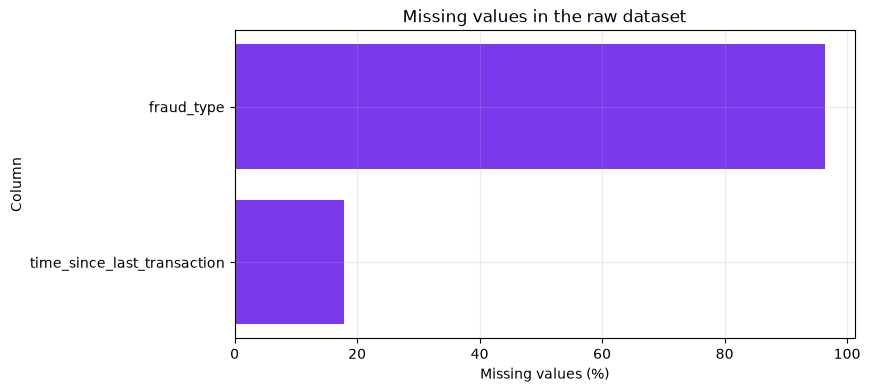

In [6]:
missing_plot = schema.loc[schema["missing_count"] > 0].sort_values("missing_percent")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_plot["column"], missing_plot["missing_percent"], color="#7c3aed")
ax.set_title("Missing values in the raw dataset")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Column")
plt.show()

## 6. Target distribution

Class imbalance affects later metric and threshold choices.


,is_fraud,row_count,percentage
0,0,4820447,96.4089
1,1,179553,3.5911


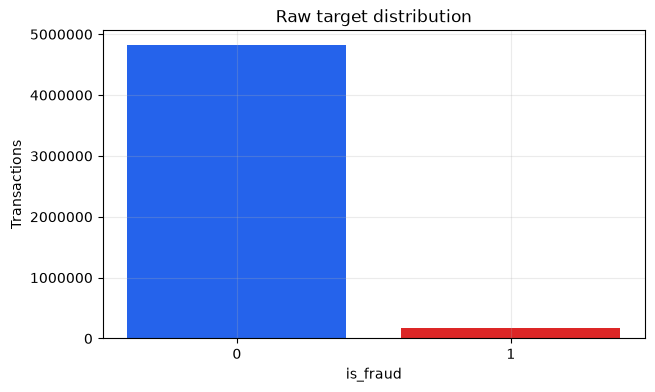

In [7]:
target_distribution = (df[TARGET].astype("Int8").value_counts().rename_axis(TARGET).reset_index(name="row_count").sort_values(TARGET))
target_distribution["percentage"] = (target_distribution["row_count"] / len(df) * 100).round(4)
display(target_distribution)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(target_distribution[TARGET].astype(str), target_distribution["row_count"], color=["#2563eb", "#dc2626"])
ax.set_title("Raw target distribution")
ax.set_xlabel("is_fraud")
ax.set_ylabel("Transactions")
ax.ticklabel_format(style="plain", axis="y")
plt.show()

## 7. Numeric distributions

The comparison between mean, median, percentiles, and extremes helps identify skewness and unusual ranges before deciding on transformations.


,feature,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,amount,5000000.0,358.9343,469.9333,0.0100,0.0100,6.1600,26.5700,138.6700,503.8900,1420.390,1875.5300,3520.5700
1,time_since_last_transaction,4103487.0,1.5258,3576.5687,-8777.8142,-7523.5249,-5990.1972,-2562.3761,0.8443,2568.3387,5993.138,7524.3183,8757.7585
2,spending_deviation_score,5000000.0,-0.0004,1.0008,-5.2600,-2.3300,-1.6500,-0.6800,0.0000,0.6700,1.650,2.3300,5.0200
3,velocity_score,5000000.0,10.5013,5.7668,1.0000,1.0000,1.0000,5.0000,11.0000,16.0000,20.000,20.0000,20.0000
4,geo_anomaly_score,5000000.0,0.5000,0.2886,0.0000,0.0100,0.0500,0.2500,0.5000,0.7500,0.950,0.9900,1.0000


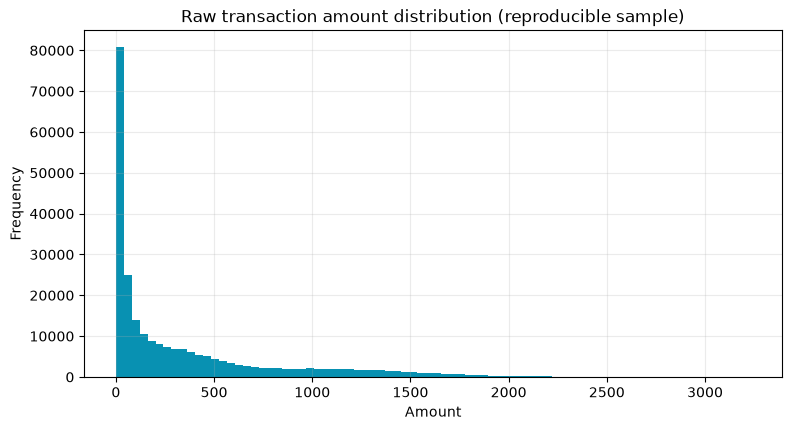

In [8]:
numeric_summary = df[NUMERIC_COLUMNS].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T.reset_index(names="feature").round(4)
display(numeric_summary)

amount_sample = df["amount"].sample(n=250_000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(amount_sample, bins=80, color="#0891b2", edgecolor="none")
ax.set_title("Raw transaction amount distribution (reproducible sample)")
ax.set_xlabel("Amount")
ax.set_ylabel("Frequency")
plt.show()

## 8. Missingness by target class

A strong missingness difference can be predictive, but it may also expose a synthetic data-generation rule. It must be investigated rather than automatically accepted as a feature.


In [9]:
missingness_rows = []
for column in df.columns[df.isna().any()]:
    grouped = df.assign(_missing=df[column].isna()).groupby(TARGET, observed=True)["_missing"]
    for target_value, values in grouped:
        missingness_rows.append({
            "column": column, TARGET: int(target_value), "row_count": int(values.size),
            "missing_count": int(values.sum()), "missing_percent": values.mean() * 100,
        })
missingness_by_target = pd.DataFrame(missingness_rows).round(4)
display(missingness_by_target)

,column,is_fraud,row_count,missing_count,missing_percent
0,fraud_type,0,4820447,4820447,100.0000
1,fraud_type,1,179553,0,0.0000
2,time_since_last_transaction,0,4820447,896513,18.5981
3,time_since_last_transaction,1,179553,0,0.0000


## 9. Identifier cardinality and target-leakage check


In [10]:
identifier_rows = []
for column in IDENTIFIER_COLUMNS:
    unique_count = int(df[column].nunique(dropna=True))
    identifier_rows.append({
        "column": column, "unique_count": unique_count,
        "cardinality_ratio": unique_count / len(df),
        "repeated_non_missing_values": int(df[column].notna().sum() - unique_count),
    })
identifier_summary = pd.DataFrame(identifier_rows).round(6)
display(identifier_summary)

fraud_type_audit = (
    df.assign(fraud_type_present=df["fraud_type"].notna())
      .groupby(TARGET, observed=True)
      .agg(row_count=(TARGET, "size"), fraud_type_present=("fraud_type_present", "sum"))
      .reset_index()
)
fraud_type_audit["fraud_type_present_percent"] = fraud_type_audit["fraud_type_present"] / fraud_type_audit["row_count"] * 100
display(fraud_type_audit.round(4))

,column,unique_count,cardinality_ratio,repeated_non_missing_values
0,transaction_id,5000000,1.000000,0
1,sender_account,896513,0.179303,4103487
2,receiver_account,896639,0.179328,4103361
3,ip_address,4997068,0.999414,2932
4,device_hash,3835723,0.767145,1164277


,is_fraud,row_count,fraud_type_present,fraud_type_present_percent
0,False,4820447,0,0.0
1,True,179553,179553,100.0


`fraud_type` is present for every fraud case and absent for every non-fraud case. It directly reveals the label and must not be used as a predictor.


## 10. Categorical patterns

These summaries describe group sizes and fraud rates. They are exploratory and are not target encodings or feature selection.


In [11]:
categorical_summaries = {}
for column in CATEGORICAL_COLUMNS:
    summary = (df.groupby(column, observed=True, dropna=False).agg(row_count=(TARGET, "size"), fraud_count=(TARGET, "sum")).reset_index())
    summary["row_percent"] = summary["row_count"] / len(df) * 100
    summary["fraud_rate"] = summary["fraud_count"] / summary["row_count"]
    summary = summary.sort_values(["fraud_rate", "row_count"], ascending=[False, False]).round(6)
    categorical_summaries[column] = summary
    print(column)
    display(summary)

transaction_type


,transaction_type,row_count,fraud_count,row_percent,fraud_rate
2,transfer,1250334,45328,25.00668,0.036253
3,withdrawal,1248635,44874,24.9727,0.035938
0,deposit,1250593,44786,25.01186,0.035812
1,payment,1250438,44565,25.00876,0.03564


merchant_category


,merchant_category,row_count,fraud_count,row_percent,fraud_rate
3,other,624589,22556,12.49178,0.036113
0,entertainment,625332,22573,12.50664,0.036098
1,grocery,624954,22516,12.49908,0.036028
6,travel,625656,22503,12.51312,0.035967
5,retail,626319,22453,12.52638,0.035849
2,online,623581,22324,12.47162,0.0358
4,restaurant,625483,22367,12.50966,0.03576
7,utilities,624086,22261,12.48172,0.03567


location


,location,row_count,fraud_count,row_percent,fraud_rate
7,Toronto,624349,22501,12.48698,0.036039
2,London,624256,22478,12.48512,0.036008
5,Sydney,625125,22458,12.5025,0.035926
4,Singapore,625313,22461,12.50626,0.03592
3,New York,625354,22460,12.50708,0.035916
0,Berlin,625289,22435,12.50578,0.035879
6,Tokyo,625994,22420,12.51988,0.035815
1,Dubai,624320,22340,12.4864,0.035783


device_used


,device_used,row_count,fraud_count,row_percent,fraud_rate
0,atm,1249640,45217,24.9928,0.036184
2,pos,1249158,44852,24.98316,0.035906
3,web,1250071,44807,25.00142,0.035844
1,mobile,1251131,44677,25.02262,0.035709


payment_channel


,payment_channel,row_count,fraud_count,row_percent,fraud_rate
3,wire_transfer,1251219,45034,25.02438,0.035992
1,UPI,1248847,44896,24.97694,0.03595
2,card,1249693,44885,24.99386,0.035917
0,ACH,1250241,44738,25.00482,0.035784


## 11. Temporal patterns

Temporal differences motivate later experiments, but time-derived features should be evaluated only after an original-feature baseline is established.


,hour,row_count,fraud_count,fraud_rate
0,0,208141,7572,0.036379
1,1,207952,7462,0.035883
2,2,208680,7385,0.035389
3,3,208256,7497,0.035999
4,4,208532,7559,0.036249
5,5,209498,7580,0.036182
6,6,208093,7512,0.036099
7,7,208114,7515,0.036110
8,8,208967,7627,0.036499
9,9,208983,7428,0.035544


,day_of_week,row_count,fraud_count,fraud_rate
0,0,718522,25591,0.035616
1,1,712879,25803,0.036195
2,2,713757,25463,0.035675
3,3,712090,25420,0.035698
4,4,712019,25589,0.035939
5,5,711420,25646,0.036049
6,6,719313,26041,0.036203


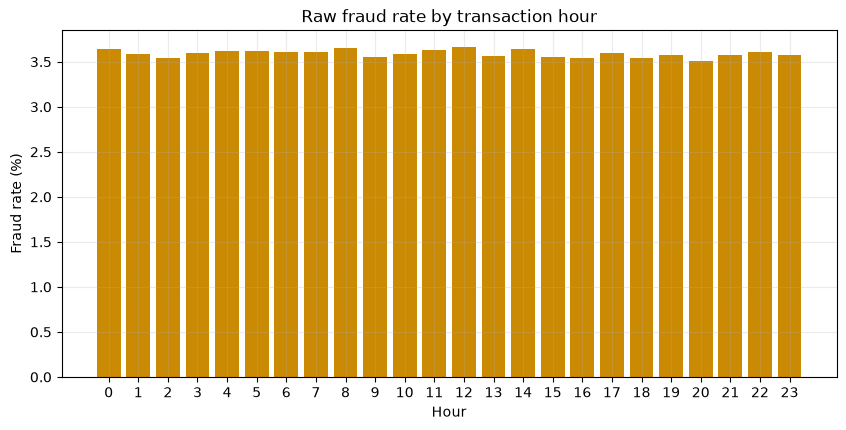

In [12]:
valid_timestamp = parsed_timestamp.notna()
temporal = pd.DataFrame({
    TARGET: df.loc[valid_timestamp, TARGET].astype("int8"),
    "hour": parsed_timestamp.loc[valid_timestamp].dt.hour,
    "day_of_week": parsed_timestamp.loc[valid_timestamp].dt.dayofweek,
})
hourly_summary = temporal.groupby("hour").agg(row_count=(TARGET, "size"), fraud_count=(TARGET, "sum")).reset_index()
hourly_summary["fraud_rate"] = hourly_summary["fraud_count"] / hourly_summary["row_count"]
weekday_summary = temporal.groupby("day_of_week").agg(row_count=(TARGET, "size"), fraud_count=(TARGET, "sum")).reset_index()
weekday_summary["fraud_rate"] = weekday_summary["fraud_count"] / weekday_summary["row_count"]
display(hourly_summary.round(6))
display(weekday_summary.round(6))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(hourly_summary["hour"].astype(str), hourly_summary["fraud_rate"] * 100, color="#ca8a04")
ax.set_title("Raw fraud rate by transaction hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Fraud rate (%)")
plt.show()

## 12. Findings that guide the next stage

This table makes the link between exploration and preparation explicit. Feature ideas remain experiments, not assumptions.


In [13]:
decision_trace = pd.DataFrame([
    ("All timestamps parse with an ISO-8601-aware parser.", "Preserve every row and use the same explicit parser during preparation."),
    ("There are no exact duplicates, duplicate transaction IDs, negative amounts, or zero amounts.", "Do not remove rows for conditions that are absent; retain validation checks."),
    (f"Amount mean is {df['amount'].mean():.2f}, while its median is {df['amount'].median():.2f}.", "Keep raw amount in the baseline and test log1p(amount) separately."),
    (f"time_since_last_transaction is missing in {df['time_since_last_transaction'].isna().mean() * 100:.2f}% of rows and only among non-fraud cases.", "Preserve missing values for train-fitted imputation and test the missingness flag separately; discuss possible generation bias."),
    ("fraud_type perfectly reveals the fraud label.", "Exclude fraud_type from every model feature set."),
    ("Account, IP, and device identifiers have high cardinality.", "Exclude them from the initial baseline; any entity-aware use requires a separate design."),
    ("The timestamp contains hour and weekday information.", "Test time-derived features only after recording the original-feature baseline."),
], columns=["raw-data observation", "next action"])
display(decision_trace)

,raw-data observation,next action
0,All timestamps parse with an ISO-8601-aware pa...,Preserve every row and use the same explicit p...
1,"There are no exact duplicates, duplicate trans...",Do not remove rows for conditions that are abs...
2,"Amount mean is 358.93, while its median is 138...",Keep raw amount in the baseline and test log1p...
3,time_since_last_transaction is missing in 17.9...,Preserve missing values for train-fitted imput...
4,fraud_type perfectly reveals the fraud label.,Exclude fraud_type from every model feature set.
5,"Account, IP, and device identifiers have high ...",Exclude them from the initial baseline; any en...
6,The timestamp contains hour and weekday inform...,Test time-derived features only after recordin...


## Conclusion

The initial EDA is now complete. The next stage is a separate cleaning and preparation workflow based on the observations above. A post-cleaning EDA will then validate the resulting table. Model-driven feature engineering will be evaluated later against a tracked baseline.
